<a href="https://colab.research.google.com/github/sgaddam31-max/PRODIGY_DS_Task-4/blob/main/PRODIGY_DS_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from textblob import TextBlob

### Unzip the data file

First, I'll unzip the `twitter_training.csv task 4.zip` file to access the CSV data.

In [ ]:
!unzip -o '/content/twitter_training.csv task 4.zip'

Archive:  /content/twitter_training.csv task 4.zip
  inflating: twitter_training.csv    


### Load the data into a Pandas DataFrame

Now, I'll load the `twitter_training.csv` file into a pandas DataFrame and display the first few rows and information about the DataFrame to understand its structure.

In [ ]:
try:
    df = pd.read_csv('twitter_training.csv')
    print("DataFrame loaded successfully.")
    display(df.head())
    print("\nDataFrame Info:")
    df.info()
except FileNotFoundError:
    print("Error: 'twitter_training.csv' not found. Please ensure the file was unzipped correctly.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

DataFrame loaded successfully.


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


### Prepare for Sentiment Analysis

Before performing sentiment analysis, I'll download necessary NLTK data and define a function to classify sentiment using `TextBlob`.

In [ ]:
nltk.download('punkt')

def get_sentiment(text):
    if isinstance(text, str):
        analysis = TextBlob(text)
        if analysis.sentiment.polarity > 0:
            return 'Positive'
        elif analysis.sentiment.polarity < 0:
            return 'Negative'
        else:
            return 'Neutral'
    else:
        return 'Neutral' # Handle non-string values as neutral

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


### Preprocessing and Sentiment Application

First, I'll rename the columns for clarity, as the current names (`2401`, `Borderlands`, `Positive`, `im getting on borderlands and i will murder you all ,`) are not very descriptive. Then, I'll apply the `get_sentiment` function to the text column to calculate the sentiment for each tweet.

In [ ]:
# Rename columns for clarity
df.columns = ['tweet_id', 'entity', 'sentiment_label', 'tweet_text']

# Apply sentiment analysis
df['predicted_sentiment'] = df['tweet_text'].apply(get_sentiment)

print("DataFrame with predicted sentiment:")
display(df.head())

print("\nPredicted Sentiment Distribution:")
print(df['predicted_sentiment'].value_counts())

DataFrame with predicted sentiment:


,tweet_id,entity,sentiment_label,tweet_text,predicted_sentiment
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,Neutral
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,Neutral
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,Neutral
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,Neutral
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,Neutral



Predicted Sentiment Distribution:
predicted_sentiment
Positive    34074
Negative    21358
Neutral     19249
Name: count, dtype: int64


### Visualize Sentiment Distribution

Now, let's visualize the distribution of the predicted sentiments.

/tmp/ipykernel_3090/2580033084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=df, palette='viridis')


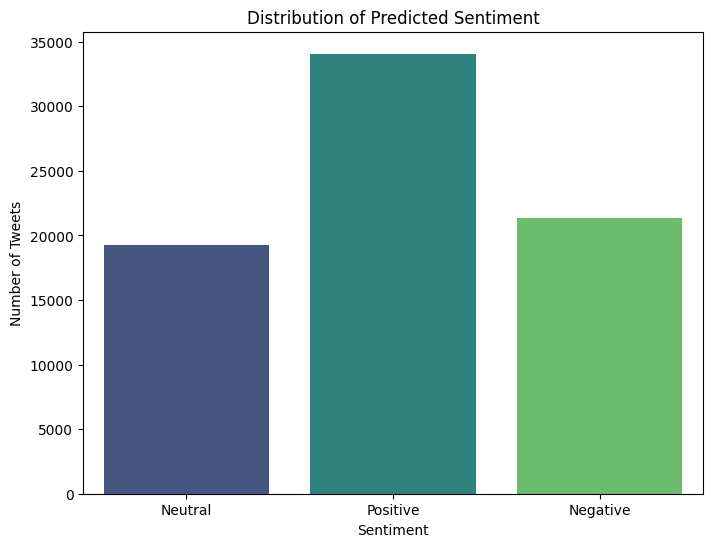

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='predicted_sentiment', data=df, palette='viridis')
plt.title('Distribution of Predicted Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

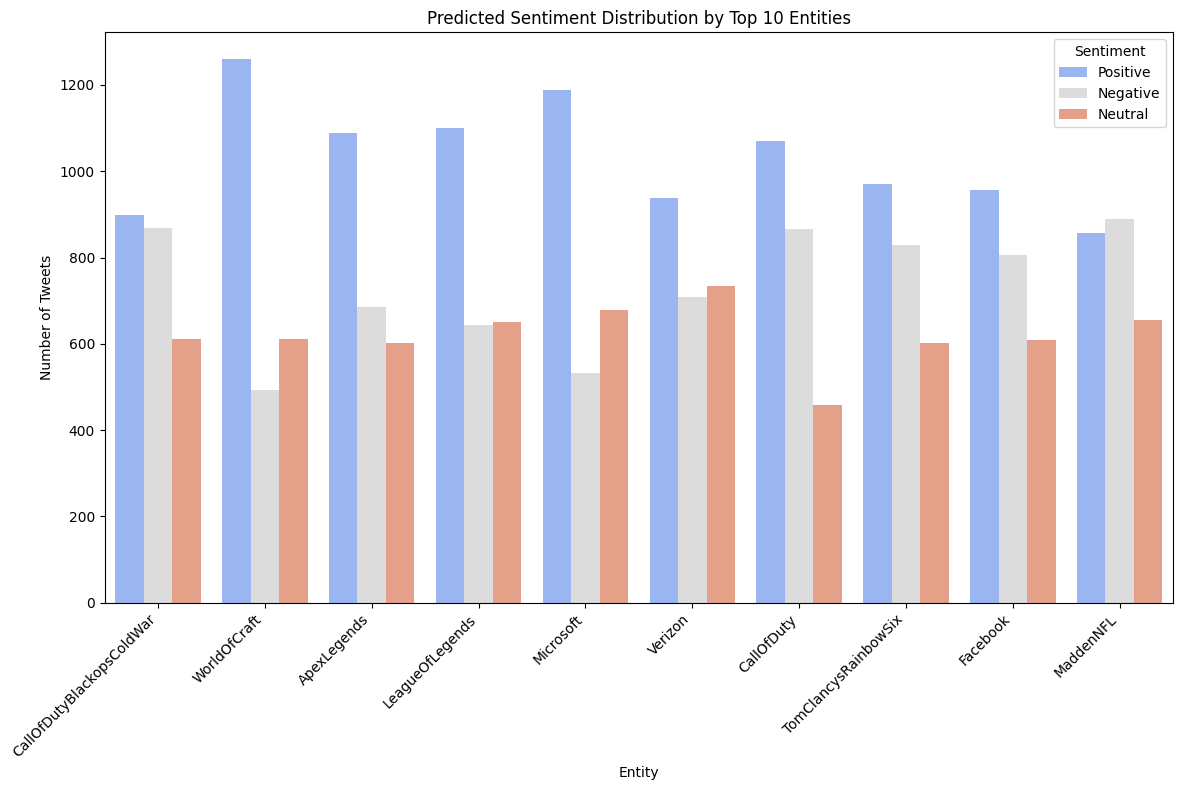

In [ ]:
# Get top 10 entities for better visualization
top_entities = df['entity'].value_counts().nlargest(10).index
df_top_entities = df[df['entity'].isin(top_entities)]

plt.figure(figsize=(12, 8))
sns.countplot(x='entity', hue='predicted_sentiment', data=df_top_entities, palette='coolwarm')
plt.title('Predicted Sentiment Distribution by Top 10 Entities')
plt.xlabel('Entity')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()